# Day 5 - Linear Regression Forecasting

## Objective

Today we build our first forecasting model using Linear Regression.

Steps:

- Load engineered dataset
- Select features
- Train/Test split
- Train Linear Regression
- Evaluate model
- Visualize predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
forecast_df = pd.read_csv(
    "../data/processed/forecast_features.csv"
)

forecast_df["Order Date"] = pd.to_datetime(
    forecast_df["Order Date"]
)

print("Forecast dataset loaded successfully.")

print(forecast_df.shape)

forecast_df.head()

Forecast dataset loaded successfully.
(1200, 15)


,Order Date,Sales,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30
0,2015-02-14,576.726,2015,2,1,7,14,5,45,1,129.568,97.112,16.448,487.067143,612.546233
1,2015-02-15,21.360,2015,2,1,7,15,6,46,1,576.726,134.384,288.060,470.920857,603.656233
2,2015-02-16,9.040,2015,2,1,8,16,0,47,0,21.360,330.512,19.536,424.996286,603.306367
3,2015-02-17,54.208,2015,2,1,8,17,1,48,0,9.040,180.320,4407.100,406.980286,458.209967
4,2015-02-18,37.784,2015,2,1,8,18,2,49,0,54.208,14.560,87.158,410.298000,456.564167


In [4]:
X = forecast_df.drop(
    columns=[
        "Order Date",
        "Sales"
    ]
)

y = forecast_df["Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (1200, 13)
Target shape: (1200,)


,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30
0,2015,2,1,7,14,5,45,1,129.568,97.112,16.448,487.067143,612.546233
1,2015,2,1,7,15,6,46,1,576.726,134.384,288.060,470.920857,603.656233
2,2015,2,1,8,16,0,47,0,21.360,330.512,19.536,424.996286,603.306367
3,2015,2,1,8,17,1,48,0,9.040,180.320,4407.100,406.980286,458.209967
4,2015,2,1,8,18,2,49,0,54.208,14.560,87.158,410.298000,456.564167


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (960, 13)
Testing Features : (240, 13)
Training Labels : (960,)
Testing Labels  : (240,)


In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [7]:
predictions = model.predict(X_test)

print(predictions[:10])

[4093.12782416 4065.24398061 1360.90204433 1795.2246354  1554.64182146
 2978.79544969 2218.58931856  892.38989093  640.93848687 3513.9488164 ]


In [8]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 1358.46
RMSE : 2313.59
R²   : 0.2392


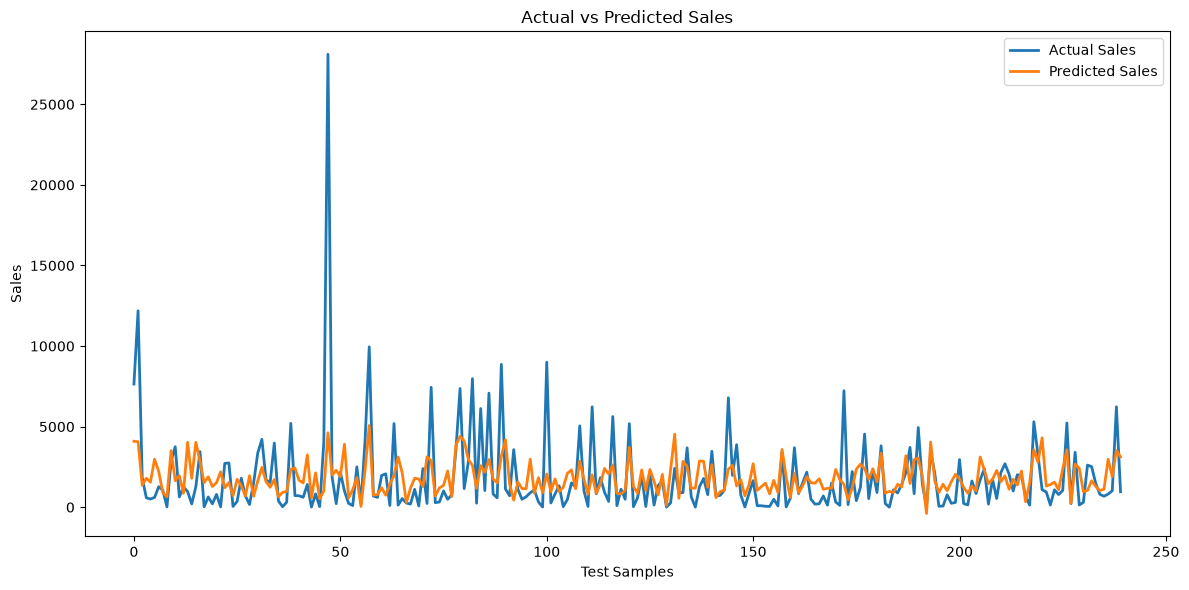

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    predictions,
    label="Predicted Sales",
    linewidth=2
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

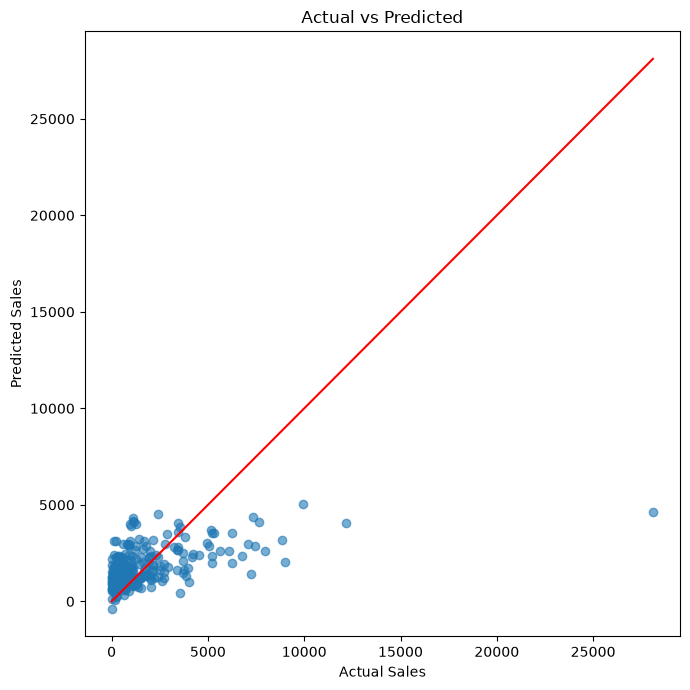

In [10]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.tight_layout()
plt.show()

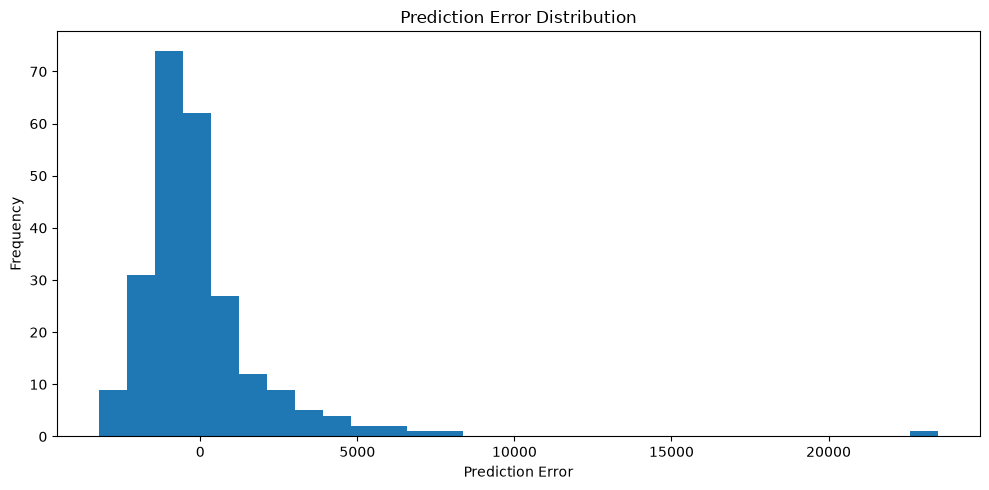

In [11]:
errors = y_test - predictions

plt.figure(figsize=(10,5))

plt.hist(
    errors,
    bins=30
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [12]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")

plt.tight_layout()

plt.savefig("../charts/actual_vs_predicted.png")

plt.close()

In [13]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Regression Predictions")

plt.tight_layout()

plt.savefig("../charts/regression_scatter.png")

plt.close()

In [14]:
plt.figure(figsize=(10,5))

plt.hist(errors, bins=30)

plt.title("Prediction Error Distribution")

plt.tight_layout()

plt.savefig("../charts/prediction_error_distribution.png")

plt.close()

print("Charts saved successfully.")

Charts saved successfully.


In [15]:
import pickle

with open("../models/linear_regression.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully.")

Model saved successfully.


# Day 5 Summary

## Tasks Completed

- Loaded engineered forecasting dataset.
- Selected forecasting features.
- Split dataset into training and testing sets.
- Trained Linear Regression model.
- Generated predictions.
- Evaluated model performance.
- Created visualization charts.
- Saved trained model.

---

## Model Performance

- MAE : 1358.46
- RMSE : 2313.59
- R² Score : 0.2392

---

## Files Created

models/
- linear_regression.pkl

charts/
- actual_vs_predicted.png
- regression_scatter.png
- prediction_error_distribution.png

---

## Skills Learned

- Train/Test Split
- Linear Regression
- Model Evaluation
- Regression Metrics
- Forecast Visualization
- Saving ML Models

Day 5 successfully completed.